НИРС по ТМО Перевощиков Н.Д. ИУ5Ц-84Б

#  Набор данных о биомеханических особенности пациентов-ортопедов

## О наборе данных

##### Содержание

Каждый пациент представлен в наборе данных четырнадцатью биомеханическими характеристиками, полученными из формы и ориентации таза и поясничного отдела позвоночника (каждый представляет собой колонну).:

Здесь указаны 14 параметров:
- `Pelvic_incidence` - частота заболеваний органов малого таза
- `Pelvic_tilt` - наклон таза
- `Lumbar_lordosis_angle` - угол поясничного лордоза
- `Sacral_slope` - наклон крестца
- `Pelvic_radius` - радиус таза
- `Degree_spondylolisthesis` - степень спондилолистеза
- `Pelvic_slope` - тазовый склон
- `Direct_tilt` - прямой наклон
- `Thoracic_slope` - грудной склон
- `Cervical_tilt` - шейный склон
- `Sacrum_angle` - крестцовый угол
- `Scoliosis_slope` - сколиозный склон
- `Class_att` - класс (Аномалия/норма)
- `To_drop` - снижение

Ссылка kaggle: https://www.kaggle.com/datasets/yassine9/dataset-spine

Целевой признак будет - Pelvic_incidence - частота заболеваний органов малого таза

## 1) Поиск и выбор набора данных для построения моделей машинного обучения.

In [1]:
# Подключаем библиотеки
import numpy as np
import pandas as pd
import seaborn as sns
import streamlit as st
import matplotlib.pyplot as plt
from catboost import Pool, CatBoostClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split, learning_curve
#from sklearn.metrics import plot_confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, median_absolute_error, r2_score 
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.svm import SVC, NuSVC, LinearSVC, OneClassSVM, SVR, NuSVR, LinearSVR
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import ExtraTreesClassifier, ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline 
sns.set(style="ticks")

In [2]:
# Подключение датасета
col_list = ['Pelvic_incidence',
            'Pelvic_tilt',
            'Lumbar_lordosis_angle',
            'Sacral_slope',
            'Pelvic_radius',
            'Degree_spondylolisthesis',
            'Pelvic_slope',
            'Direct_tilt',
            'Thoracic_slope',
            'Cervical_tilt',
            'Sacrum_angle',
            'Scoliosis_slope',
            'Class_att',
            'To_drop']

try:
    data = pd.read_csv('Dataset_spine.csv', names=col_list, header=1, sep=",")
    data.drop('To_drop', axis=1, inplace=True)
    print("Файл успешно загружен.")
except FileNotFoundError:
    print("Файл не найден.")

Файл успешно загружен.


## 2) Проведение разведочного анализа данных. Построение графиков, необходимых для понимания структуры данных. Анализ и заполнение пропусков в данных.

In [3]:
# Выводим информацию о датасета
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pelvic_incidence          309 non-null    float64
 1   Pelvic_tilt               309 non-null    float64
 2   Lumbar_lordosis_angle     309 non-null    float64
 3   Sacral_slope              309 non-null    float64
 4   Pelvic_radius             309 non-null    float64
 5   Degree_spondylolisthesis  309 non-null    float64
 6   Pelvic_slope              309 non-null    float64
 7   Direct_tilt               309 non-null    float64
 8   Thoracic_slope            309 non-null    float64
 9   Cervical_tilt             309 non-null    float64
 10  Sacrum_angle              309 non-null    float64
 11  Scoliosis_slope           309 non-null    float64
 12  Class_att                 309 non-null    object 
dtypes: float64(12), object(1)
memory usage: 31.5+ KB


In [4]:
# Выводим первые 5 строк датасета
data.head()

,Pelvic_incidence,Pelvic_tilt,Lumbar_lordosis_angle,Sacral_slope,Pelvic_radius,Degree_spondylolisthesis,Pelvic_slope,Direct_tilt,Thoracic_slope,Cervical_tilt,Sacrum_angle,Scoliosis_slope,Class_att
0,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,0.415186,12.8874,17.5323,16.78486,-25.530607,16.1102,Abnormal
1,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,0.474889,26.8343,17.4861,16.65897,-29.031888,19.2221,Abnormal
2,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,0.369345,23.5603,12.7074,11.42447,-30.470246,18.8329,Abnormal
3,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,0.543360,35.4940,15.9546,8.87237,-16.378376,24.9171,Abnormal
4,40.250200,13.921907,25.124950,26.328293,130.327871,2.230652,0.789993,29.3230,12.0036,10.40462,-1.512209,9.6548,Abnormal


In [5]:
# Подсчитаем количество строк и столбцов в датасете
num_rows, num_cols = data.shape
# Выводим результат
print(f"Количество столбцов: {num_cols}, количество строк: {num_rows}")

Количество столбцов: 13, количество строк: 309


In [6]:
# Выводим названия колонок
data.columns

Index(['Pelvic_incidence', 'Pelvic_tilt', 'Lumbar_lordosis_angle',
       'Sacral_slope', 'Pelvic_radius', 'Degree_spondylolisthesis',
       'Pelvic_slope', 'Direct_tilt', 'Thoracic_slope', 'Cervical_tilt',
       'Sacrum_angle', 'Scoliosis_slope', 'Class_att'],
      dtype='object')

In [7]:
# Выводим типы колонок
data.dtypes

Pelvic_incidence            float64
Pelvic_tilt                 float64
Lumbar_lordosis_angle       float64
Sacral_slope                float64
Pelvic_radius               float64
Degree_spondylolisthesis    float64
Pelvic_slope                float64
Direct_tilt                 float64
Thoracic_slope              float64
Cervical_tilt               float64
Sacrum_angle                float64
Scoliosis_slope             float64
Class_att                    object
dtype: object

In [8]:
# Проверим датасет на пропуски
data.isnull().sum()

Pelvic_incidence            0
Pelvic_tilt                 0
Lumbar_lordosis_angle       0
Sacral_slope                0
Pelvic_radius               0
Degree_spondylolisthesis    0
Pelvic_slope                0
Direct_tilt                 0
Thoracic_slope              0
Cervical_tilt               0
Sacrum_angle                0
Scoliosis_slope             0
Class_att                   0
dtype: int64

In [9]:
# Проверим датасет на дубликаты
data.duplicated().sum()

0

Пропусков и дубликатов нет, это говорится о том, что датасет был сделан хорошо.

Преобразуем категориальные значения в столбце 'Class_att' (например, 'Abnormal' и 'Normal') в числовые значения (1 и 0 соответственно) и запишем их в новый столбец 'Class_att_new'. 

In [10]:
data['Class_att_new'] = data['Class_att'].map({'Abnormal': 1, 'Normal': 0})

In [11]:
# Выводим определенные столбцы из датасета
print(data.loc[:, ['Class_att', 'Class_att_new']])

    Class_att  Class_att_new
0    Abnormal              1
1    Abnormal              1
2    Abnormal              1
3    Abnormal              1
4    Abnormal              1
..        ...            ...
304    Normal              0
305    Normal              0
306    Normal              0
307    Normal              0
308    Normal              0

[309 rows x 2 columns]


In [12]:
# Подсчитаем уникальные значения в столбце датасета
data['Class_att'].value_counts()

Class_att
Abnormal    209
Normal      100
Name: count, dtype: int64

Как видим, что в столбце 'Class_att' значение 'Abnormal' встречается 209 раз, а значение 'Normal' - 100 раз.

In [13]:
# Выводим первые 5 строк датасета
data.head()

,Pelvic_incidence,Pelvic_tilt,Lumbar_lordosis_angle,Sacral_slope,Pelvic_radius,Degree_spondylolisthesis,Pelvic_slope,Direct_tilt,Thoracic_slope,Cervical_tilt,Sacrum_angle,Scoliosis_slope,Class_att,Class_att_new
0,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,0.415186,12.8874,17.5323,16.78486,-25.530607,16.1102,Abnormal,1
1,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,0.474889,26.8343,17.4861,16.65897,-29.031888,19.2221,Abnormal,1
2,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,0.369345,23.5603,12.7074,11.42447,-30.470246,18.8329,Abnormal,1
3,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,0.543360,35.4940,15.9546,8.87237,-16.378376,24.9171,Abnormal,1
4,40.250200,13.921907,25.124950,26.328293,130.327871,2.230652,0.789993,29.3230,12.0036,10.40462,-1.512209,9.6548,Abnormal,1


Набор данных не содержит пропусков, категориальные признаки закодированы.

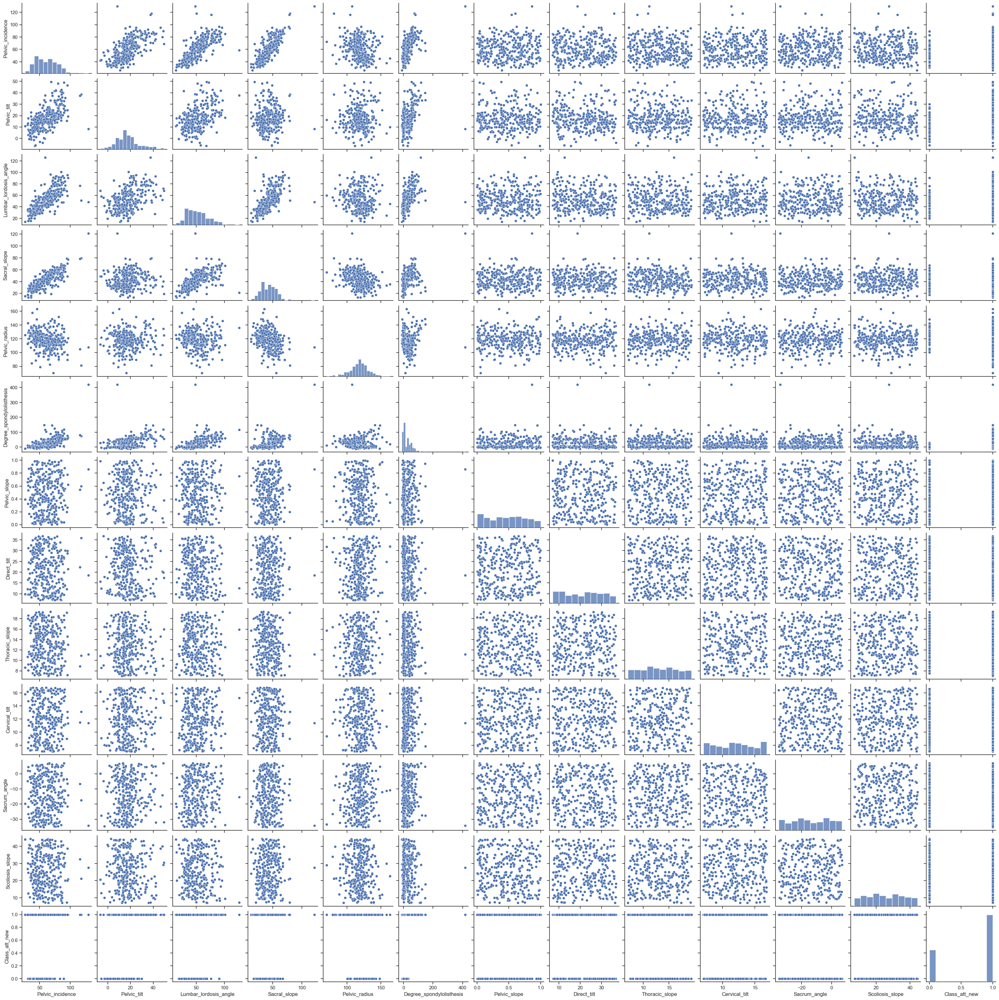

In [14]:
# Построим графики рассеяния для всех возможных пар числовых столбцов
sns.pairplot(data)

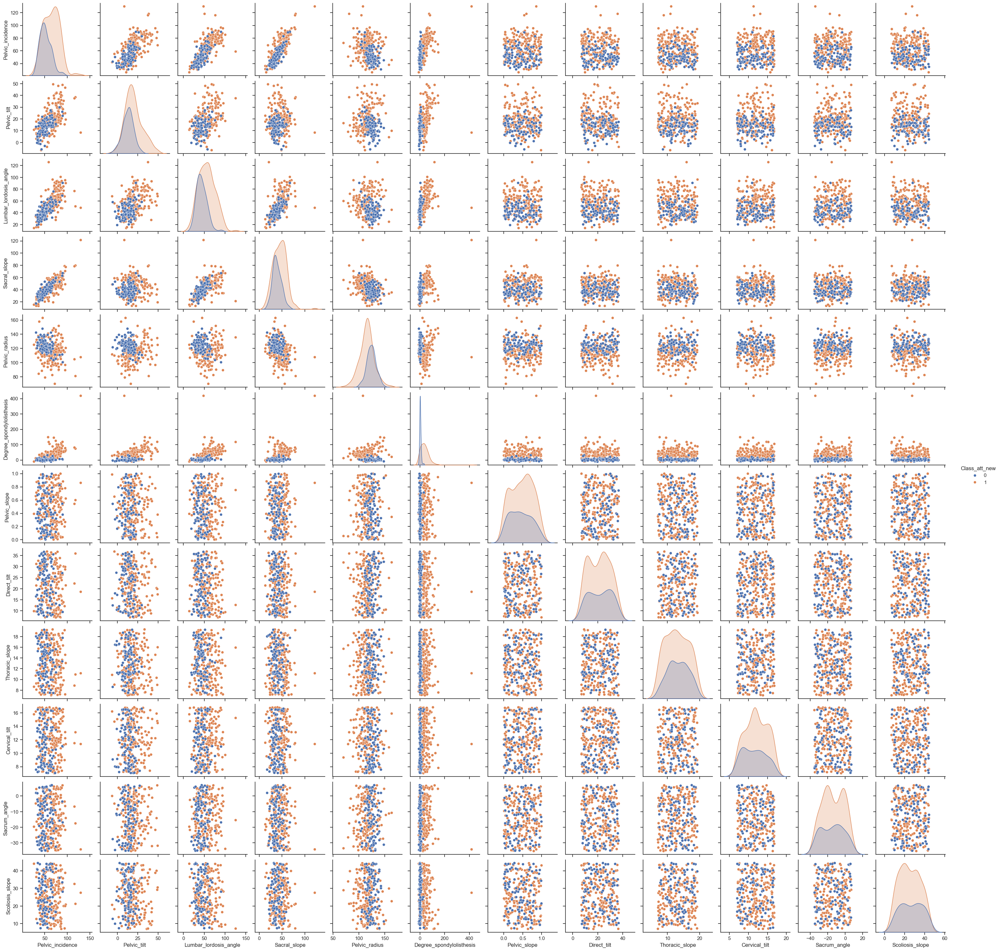

In [15]:
# Построим графики рассеяния для всех возможных пар числовых столбцов Class_att_new
sns.pairplot(data, hue="Class_att_new")

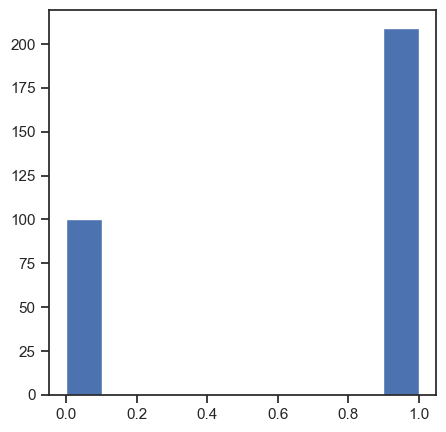

In [16]:
# Оценим дисбаланс классов для Class_att_new
fig, ax = plt.subplots(figsize=(5,5)) 
plt.hist(data['Class_att_new'])
plt.show()

In [17]:
data['Class_att_new'].value_counts()

Class_att_new
1    209
0    100
Name: count, dtype: int64

In [18]:
# Подсчитаем дисбаланс классов
total = data.shape[0]
class_0, class_1 = data['Class_att_new'].value_counts()
print('Класс 0 составляет {}%. Класс 1 составляет {}%.'
      .format(round(class_0 / total, 4)*100, round(class_1 / total, 4)*100))

Класс 0 составляет 67.64%. Класс 1 составляет 32.36%.


Класс 0 (класс "Abnormal") составляет примерно 67.64% от общего количества экземпляров, в то время как класс 1 (класс "Normal") составляет примерно 32.36%.

Вывод подтверждает наличие дисбаланса классов в данных. Преобладание одного класса над другим может оказать влияние на способность модели классификации корректно идентифицировать оба класса. В данном случае, поскольку класс 0 составляет значительную часть выборки, модель может быть склонна к неправильному классифицированию экземпляров как класса 0 даже в случае, когда они принадлежат классу 1. 

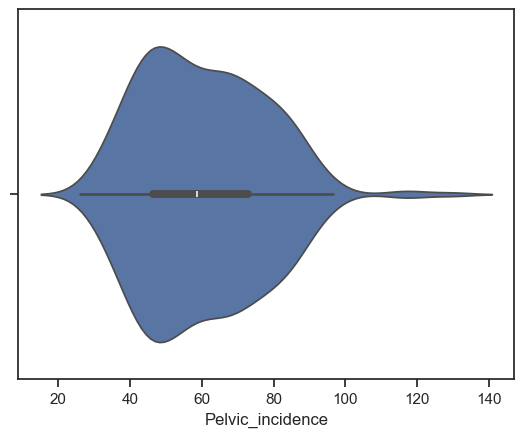

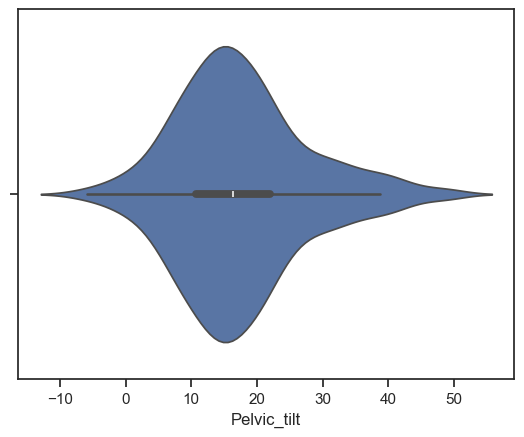

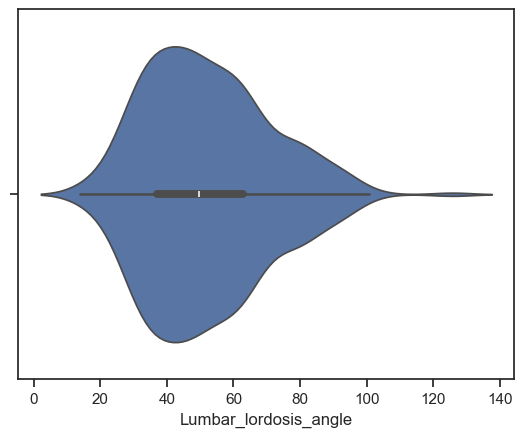

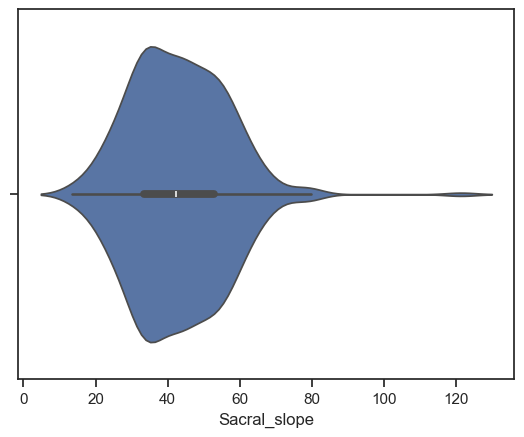

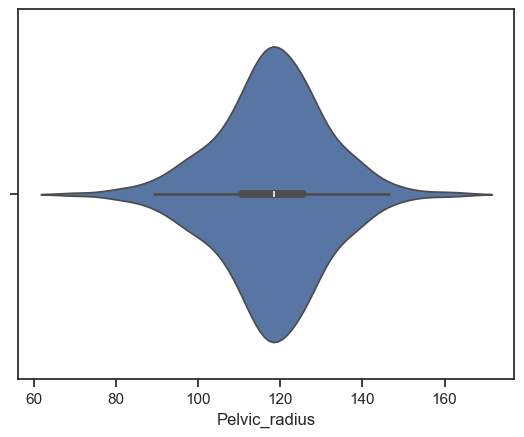

...

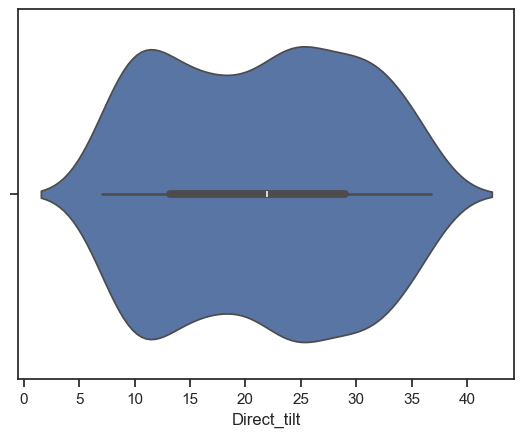

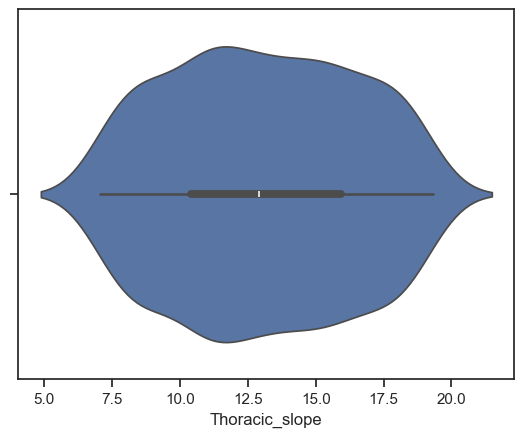

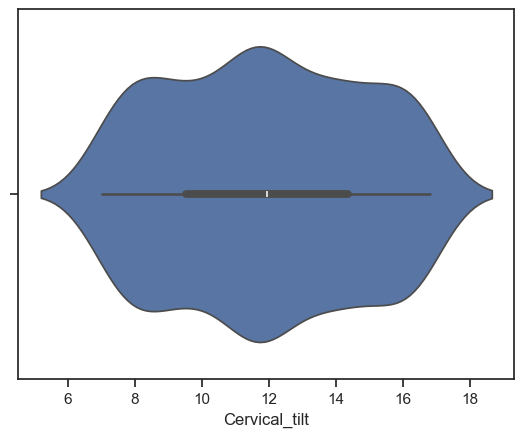

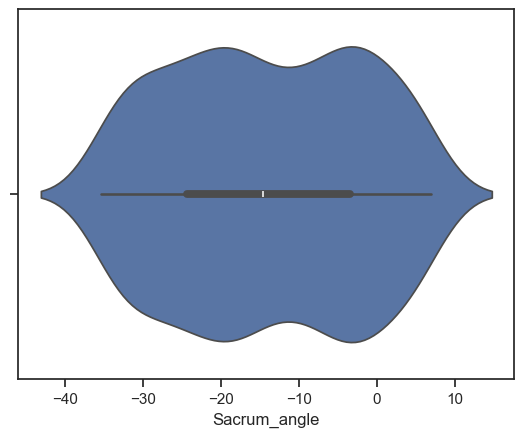

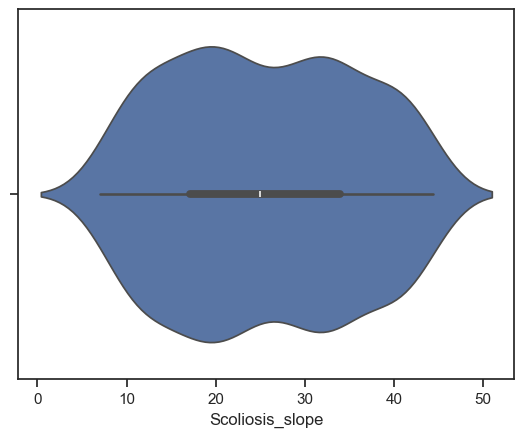

In [19]:
# Скрипичные диаграммы для числовых колонок
for col in ['Pelvic_incidence',
               'Pelvic_tilt',
               'Lumbar_lordosis_angle',
               'Sacral_slope',
               'Pelvic_radius',
               'Degree_spondylolisthesis',
               'Pelvic_slope',
               'Direct_tilt',
               'Thoracic_slope',
               'Cervical_tilt',
               'Sacrum_angle',
               'Scoliosis_slope']:
    sns.violinplot(x=data[col])
    plt.show()

1) Различие в распределении: Если формы скрипичных диаграмм для разных классов значительно отличаются (например, одна скрипичная диаграмма имеет более широкий разброс значений или имеет более выраженные хвосты), это может указывать на различия в распределении признаков между классами.

2) Выбросы и экстремальные значения: Различия в форме скрипичных диаграмм могут также указывать на наличие выбросов или экстремальных значений в одном из классов.

3) Потенциальная предсказательная сила признаков: Если форма скрипичной диаграммы для одного из классов более выражена или имеет более четкие пики, чем для другого класса, это может указывать на то, что эти признаки имеют более высокую предсказательную силу для одного из классов.

4) Важность признаков: Различия в форме скрипичных диаграмм могут помочь определить, какие признаки могут быть более важными для разделения классов.

###  3) Выбор признаков, подходящих для построения моделей. Кодирование категориальных признаков. Масштабирование данных. Формирование вспомогательных признаков, улучшающих качество моделей.

Для построения моделей будем использовать все признаки. Категориальные признаки закодированы, поэтому выполним масштабирование данных.

In [20]:
# Числовые колонки для масштабирования данных
scale_cols = ['Pelvic_incidence',
               'Pelvic_tilt',
               'Lumbar_lordosis_angle',
               'Sacral_slope',
               'Pelvic_radius',
               'Degree_spondylolisthesis',
               'Pelvic_slope',
               'Direct_tilt',
               'Thoracic_slope',
               'Cervical_tilt',
               'Sacrum_angle',
               'Scoliosis_slope']

In [21]:
sc1 = MinMaxScaler()
sc1_data = sc1.fit_transform(data[scale_cols])

In [22]:
# Добавим масштабированные данные в набор данных
for i in range(len(scale_cols)):
    col = scale_cols[i]
    new_col_name = col + '_scaled'
    data[new_col_name] = sc1_data[:,i]

In [23]:
# Выводим первые 5 строк датасета
data.head()

,Pelvic_incidence,Pelvic_tilt,Lumbar_lordosis_angle,Sacral_slope,Pelvic_radius,Degree_spondylolisthesis,Pelvic_slope,Direct_tilt,Thoracic_slope,Cervical_tilt,...,Lumbar_lordosis_angle_scaled,Sacral_slope_scaled,Pelvic_radius_scaled,Degree_spondylolisthesis_scaled,Pelvic_slope_scaled,Direct_tilt_scaled,Thoracic_slope_scaled,Cervical_tilt_scaled,Sacrum_angle_scaled,Scoliosis_slope_scaled
0,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,0.415186,12.8874,17.5323,16.78486,...,0.098578,0.144629,0.476649,0.036365,0.413783,0.197208,0.854170,0.996300,0.230878,0.243812
1,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,0.474889,26.8343,17.4861,16.65897,...,0.322995,0.307661,0.386097,0.017523,0.473750,0.666533,0.850409,0.983442,0.148026,0.327166
2,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,0.369345,23.5603,12.7074,11.42447,...,0.271260,0.289436,0.341826,0.051838,0.367741,0.556360,0.461461,0.448790,0.113989,0.316741
3,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,0.543360,35.4940,15.9546,8.87237,...,0.128129,0.247022,0.409579,0.044173,0.542524,0.957940,0.725757,0.188118,0.447450,0.479711
4,40.250200,13.921907,25.124950,26.328293,130.327871,2.230652,0.789993,29.3230,12.0036,10.40462,...,0.099559,0.119943,0.647879,0.030933,0.790245,0.750280,0.404177,0.344623,0.799234,0.070899


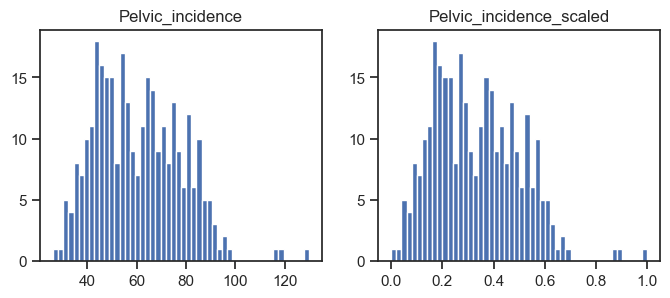

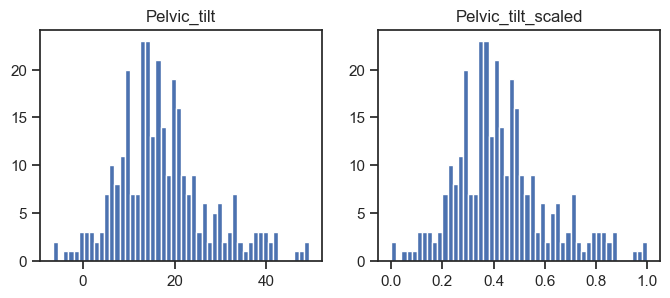

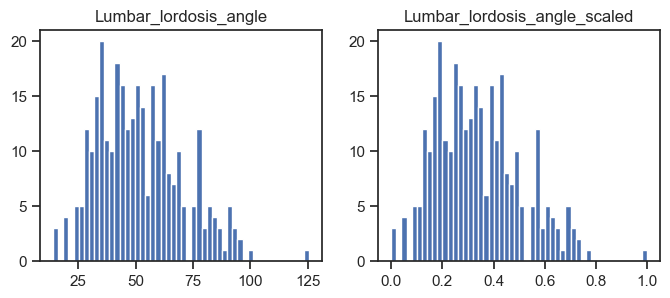

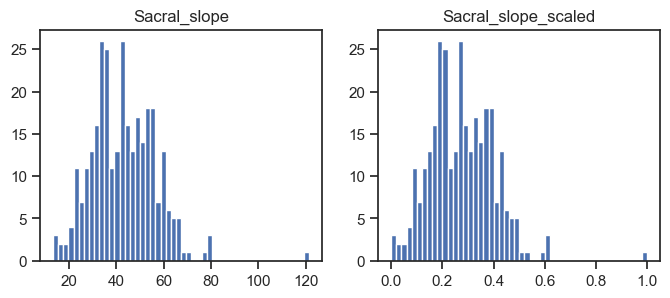

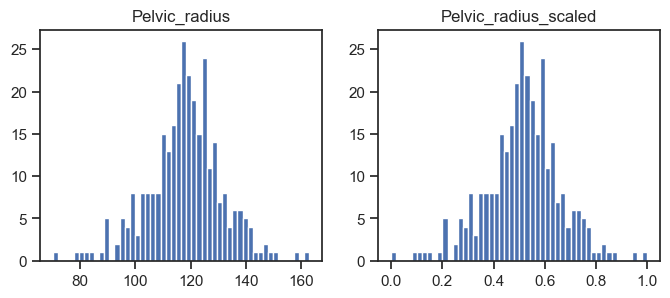

...

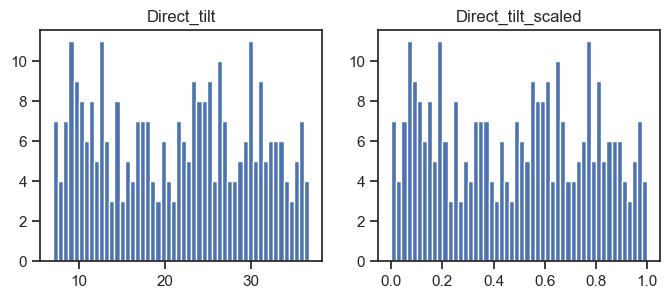

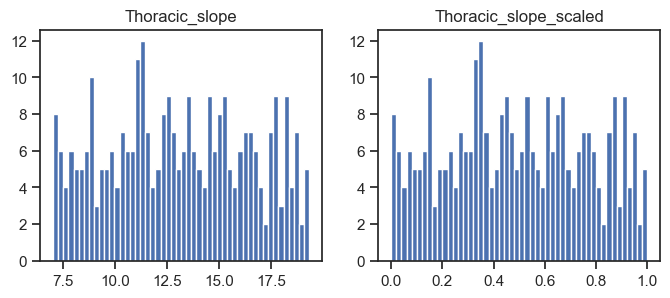

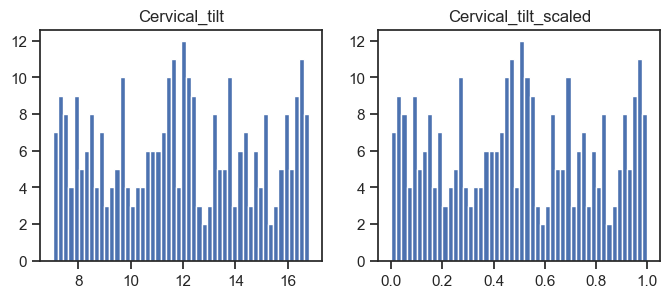

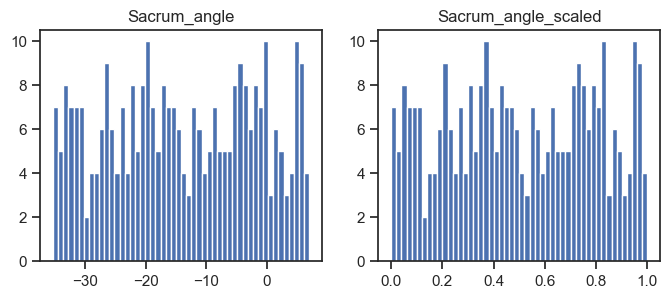

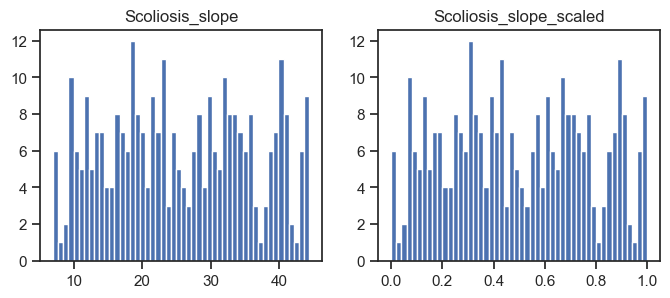

In [24]:
# Проверим, что масштабирование не повлияло на распределение данных
for col in scale_cols:
    col_scaled = col + '_scaled'

    fig, ax = plt.subplots(1, 2, figsize=(8,3))
    ax[0].hist(data[col], 50)
    ax[1].hist(data[col_scaled], 50)
    ax[0].title.set_text(col)
    ax[1].title.set_text(col_scaled)
    plt.show()


Все диаграммы имеют нормальный вид распределения.

### 4) Проведение корреляционного анализа данных. Формирование промежуточных выводов о возможности построения моделей машинного обучения.

In [25]:
# Создаем исходный список corr_cols_1
corr_cols_1 = scale_cols + ['Class_att_new']
corr_cols_1

['Pelvic_incidence',
 'Pelvic_tilt',
 'Lumbar_lordosis_angle',
 'Sacral_slope',
 'Pelvic_radius',
 'Degree_spondylolisthesis',
 'Pelvic_slope',
 'Direct_tilt',
 'Thoracic_slope',
 'Cervical_tilt',
 'Sacrum_angle',
 'Scoliosis_slope',
 'Class_att_new']

In [26]:
# Создаем новый список corr_cols_2, включающий имена столбцов, масштабированных с добавлением  суффикса "_scaled"
scale_cols_postfix = [x+'_scaled' for x in scale_cols]
corr_cols_2 = scale_cols_postfix + ['Class_att_new']
corr_cols_2

['Pelvic_incidence_scaled',
 'Pelvic_tilt_scaled',
 'Lumbar_lordosis_angle_scaled',
 'Sacral_slope_scaled',
 'Pelvic_radius_scaled',
 'Degree_spondylolisthesis_scaled',
 'Pelvic_slope_scaled',
 'Direct_tilt_scaled',
 'Thoracic_slope_scaled',
 'Cervical_tilt_scaled',
 'Sacrum_angle_scaled',
 'Scoliosis_slope_scaled',
 'Class_att_new']

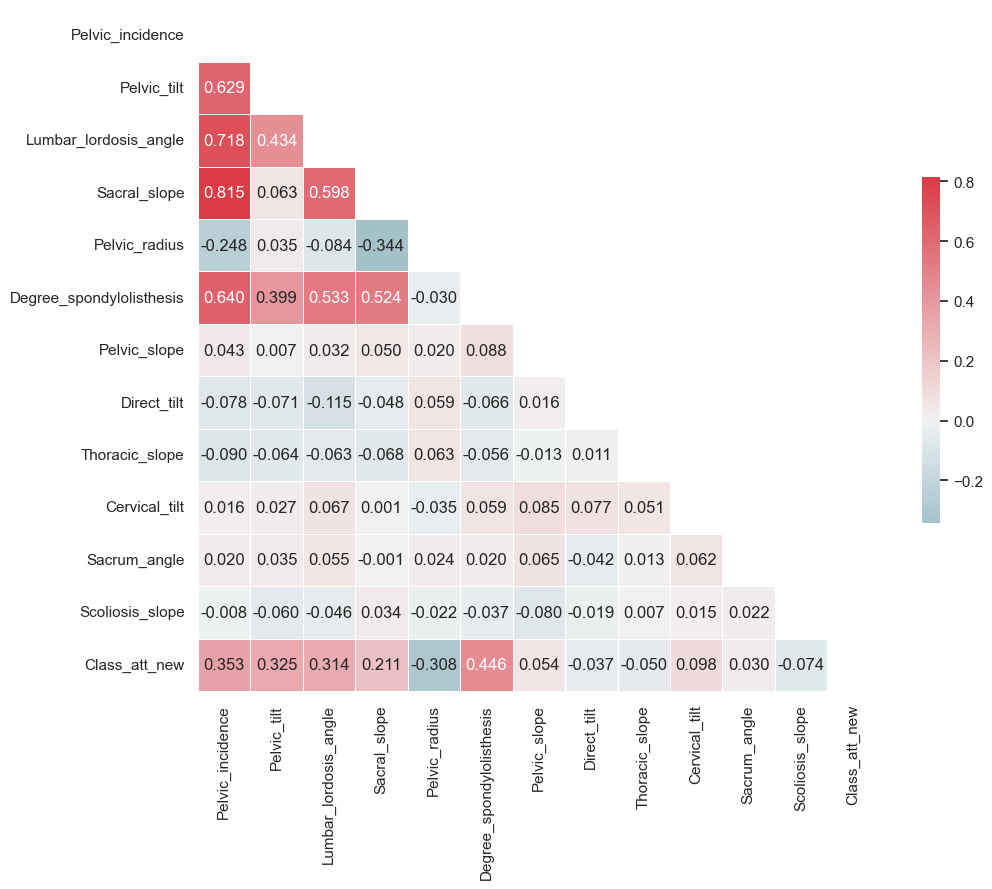

In [27]:
# Создаем корреляционную матрицу для corr_cols_1
sns.set(style="white")
corr = data[corr_cols_1].corr()
mask = np.zeros_like(corr, dtype=np.bool)
mask[np.triu_indices_from(mask)] = True
f, ax = plt.subplots(figsize=(11, 9))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
g=sns.heatmap(corr, mask=mask, cmap=cmap, center=0, annot=True, fmt='.3f',
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

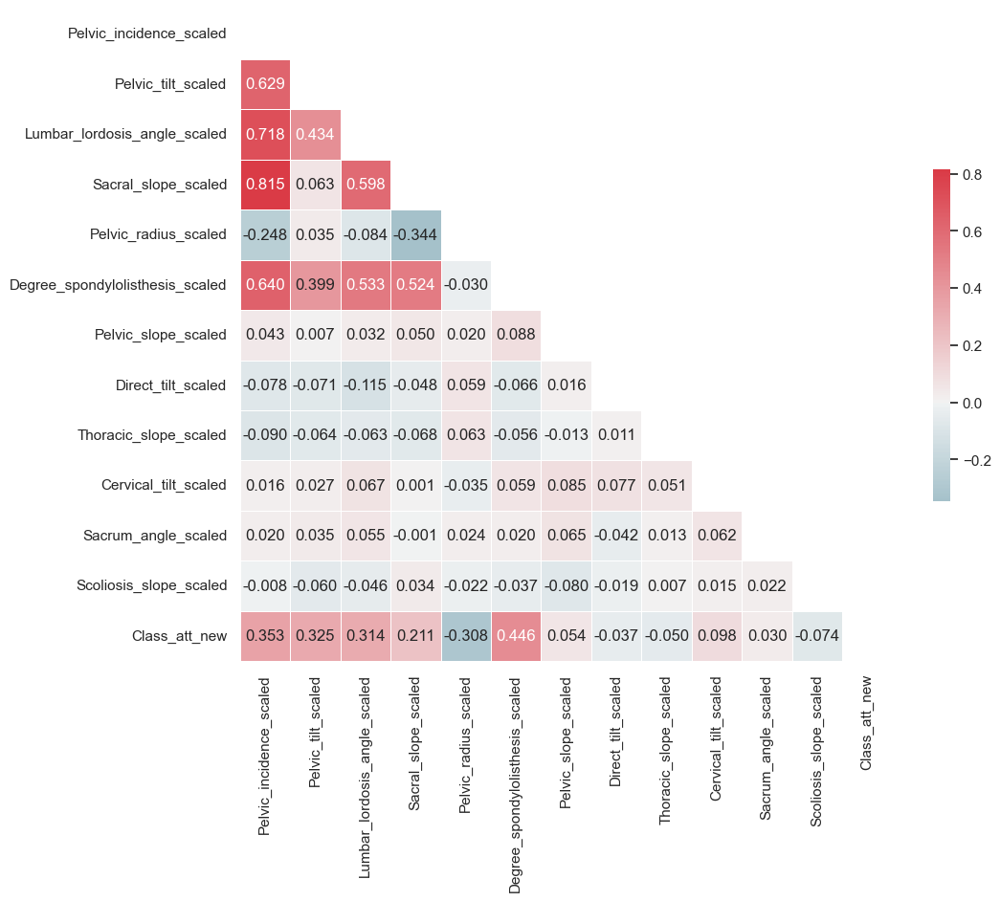

In [28]:
# Создаем корреляционную матрицу для corr_cols_2
sns.set(style="white")
corr = data[corr_cols_2].corr()
mask = np.zeros_like(corr, dtype=np.bool)
mask[np.triu_indices_from(mask)] = True
f, ax = plt.subplots(figsize=(11, 9))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
g=sns.heatmap(corr, mask=mask, cmap=cmap, center=0, annot=True, fmt='.3f',
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

На основе двух корреляционных матриц для сравнения сделаем следующие выводы:

- Корреляционные матрицы для исходных и масштабированных данных совпадают.
- Целевой признак классификации "Class_att_new" наиболее сильно коррелирует со следующими признаками:
   1. "Degree_spondylolisthesis" (0.446);
   2. "Pelvic_incidence" (0.353);
   3. "Pelvic_tilt" (0.325)
   4. "Lumbar_lordosis_angle" (0.314) Эти признаки следует оставить в модели классификации.
- А также целевые признаки класификации "Pelvic_tilt", "Lumbar_lordosis_angle", "Sacral_slope" и "Degree_spondylolisthesis" имеют очень высокие корреляции.
- На основании корреляционной матрицы можно сделать вывод о том, что данные позволяют построить модель машинного обучения.

### 5) Выбор метрик для последующей оценки качества моделей

#### В качестве метрик для решения задачи классификации будем использовать:

#### В качестве метрик для решения задачи классификации будем использовать:
- Precision - доля верно предсказанных классификатором положительных объектов, из всех объектов, которые классификатор верно или неверно определил как положительные.
- Recall - доля верно предсказанных классификатором положительных объектов, из всех действительно положительных объектов.
- F1- мера - для объединения precision и recall в единую метрику
- ROC AUC основана на вычислении следующих характеристик:
  - True Positive Rate, откладывается по оси ординат. Совпадает с recall.
  - False Positive Rate, откладывается по оси абсцисс. Показывает какую долю из объектов отрицательного класса алгоритм предсказал неверно.

In [29]:
# Отрисовка ROC-кривой
def draw_roc_curve(y_true, y_score, pos_label=1, average='micro'):
    fpr, tpr, thresholds = roc_curve(y_true, y_score, 
                                     pos_label=pos_label)
    roc_auc_value = roc_auc_score(y_true, y_score, average=average)
    plt.figure()
    lw = 2
    plt.plot(fpr, tpr, color='darkturquoise',
             lw=lw, label='ROC curve (area = %0.2f)' % roc_auc_value)
    plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic')
    plt.legend(loc="lower right")
    plt.show()

In [30]:
# Создаем класс MetricLogger
class MetricLogger:
    
    def __init__(self):
        # Инициализация пустого DataFrame с тремя столбцами: 'metric', 'alg', 'value'
        self.df = pd.DataFrame(
            {'metric': pd.Series([], dtype='str'),
            'alg': pd.Series([], dtype='str'),
            'value': pd.Series([], dtype='float')})

    def add(self, metric, alg, value):
        """
        Добавление значения
        """
        # Создание нового DataFrame из списка словарей
        temp_df = pd.DataFrame({'metric': [metric], 'alg': [alg], 'value': [value]})
        # Конкатенация нового DataFrame с существующим
        self.df = pd.concat([self.df, temp_df], ignore_index=True)


    def get_data_for_metric(self, metric, ascending=True):
        """
        Формирование данных с фильтром по метрике
        """
        # Получение данных для указанной метрики и сортировка по значению метрики
        temp_data = self.df[self.df['metric']==metric]
        temp_data_2 = temp_data.sort_values(by='value', ascending=ascending)
        return temp_data_2['alg'].values, temp_data_2['value'].values
    
    def plot(self, str_header, metric, ascending=True, figsize=(5, 5)):
        """
        Вывод графика
        """
        # Получение данных для указанной метрики и построение горизонтальной столбчатой диаграммы
        array_labels, array_metric = self.get_data_for_metric(metric, ascending)
        fig, ax1 = plt.subplots(figsize=figsize)
        pos = np.arange(len(array_metric))
        rects = ax1.barh(pos, array_metric,
                         align='center',
                         height=0.5, 
                         tick_label=array_labels)
        ax1.set_title(str_header)
        for a,b in zip(pos, array_metric):
            plt.text(0.5, a-0.05, str(round(b,3)), color='white')
        plt.show()  

### 6) Выбор наиболее подходящих моделей для решения задачи классификации

Для задачи классификации будем использовать следующие модели:

- Метод ближайших соседей
- Линейная/логистическая регрессия
- Метод опорных векторов
- Дерево решений
- Случайный лес
- Градиентный бустинг

### 7) Формирование обучающей и тестовой выборок на основе исходного набора данных.

In [31]:
# Признаки для задачи классификации
class_cols = ['Pelvic_incidence',
               'Pelvic_tilt',
               'Lumbar_lordosis_angle',
               'Degree_spondylolisthesis',
               ]

In [32]:
X = data[class_cols]
Y = data['Class_att_new']
print(f"Количество строк (наблюдений) в массиве X: {X.shape[0]}")
print(f"Количество столбцов (признаков) в массиве X: {X.shape[1]}")

Количество строк (наблюдений) в массиве X: 309
Количество столбцов (признаков) в массиве X: 4


#### Разделим выборку на обучающую и тестовую

In [33]:
# С использованием метода train_test_split разделим выборку на обучающую и тестовую
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, random_state=1)

In [34]:
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((278, 4), (31, 4), (278,), (31,))

Из итогов ((278, 4), (31, 4), (278,), (31,)) можно сделать следующие выводы:
- 	X_train содержит 278 наблюдений и 4 признака.
- 	X_test содержит 31 наблюдение и 4 признака.
- 	Y_train содержит 278 меток классов.
- 	Y_test содержит 31 меток классов.
 
Это означает, что данные были успешно разделены на обучающую и тестовую выборки. Обучающая выборка используется для обучения модели, а тестовая выборка - для оценки ее качества на данных, которые модель ранее не видела.


### 8) Построение базового решения (baseline) для выбранных моделей без подбора гиперпараметров. Производится обучение моделей на основе обучающей выборки и оценка качества моделей на основе тестовой выборки.

In [35]:
# Модели
clas_models = {'LogR': LogisticRegression(), 
               'KNN_5':KNeighborsClassifier(n_neighbors=5),
               'SVC':SVC(),
               'Tree':DecisionTreeClassifier(),
               'RF':RandomForestClassifier(),
               'GB':GradientBoostingClassifier()}

In [36]:
# Сохранение метрик
clasMetricLogger = MetricLogger()

In [37]:
# Обучающая модель
def train_model(model_name, model, MetricLogger):
    # Обучение модели
    model.fit(X_train, Y_train)
    # Получение прогнозов модели на тестовых данных
    Y_pred = model.predict(X_test)
    
    # Вычисление метрик качества модели
    precision = precision_score(Y_test, Y_pred)
    recall = recall_score(Y_test, Y_pred)
    f1 = f1_score(Y_test, Y_pred)
    roc_auc = roc_auc_score(Y_test, Y_pred)
    
    # Добавление метрик качества в MetricLogger
    MetricLogger.add('precision', model_name, precision)
    MetricLogger.add('recall', model_name, recall)
    MetricLogger.add('f1', model_name, f1)
    MetricLogger.add('roc_auc', model_name, roc_auc)

    # Вывод модели
    print(model)
    # Построение ROC-кривой
    draw_roc_curve(Y_test, Y_pred)
    
    # Получение и отображение матрицы ошибок
    cm = confusion_matrix(Y_test, Y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '1'])
    disp.plot(cmap=plt.cm.Blues, ax=None)
    plt.show()

LogisticRegression()


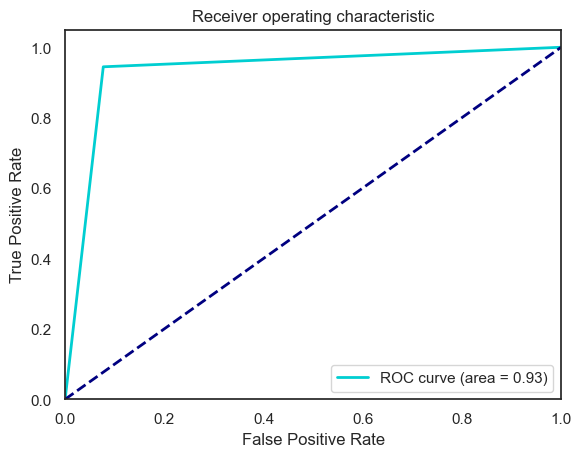

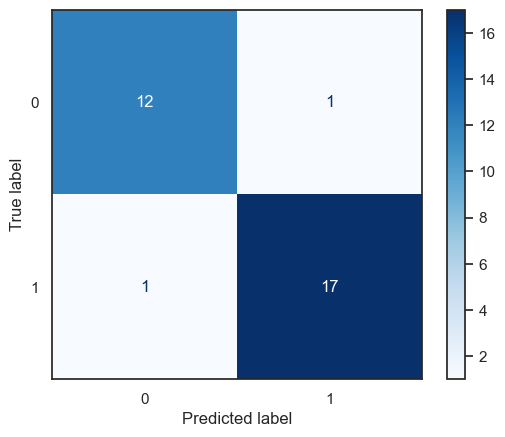

KNeighborsClassifier()


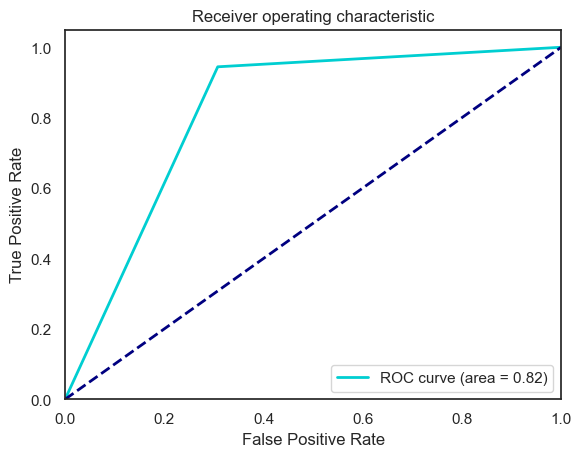

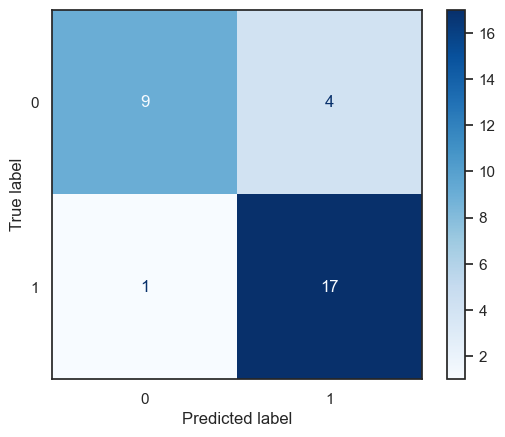

SVC()


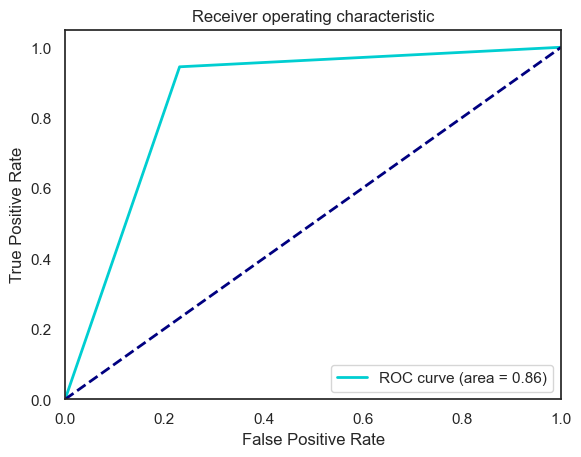

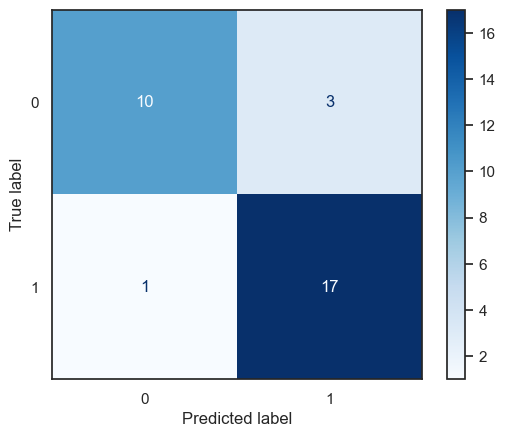

DecisionTreeClassifier()


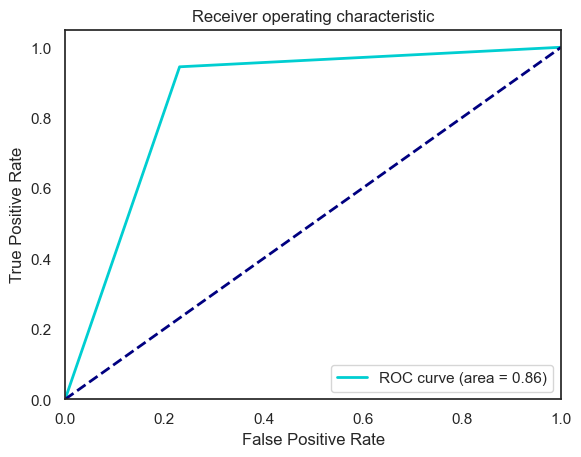

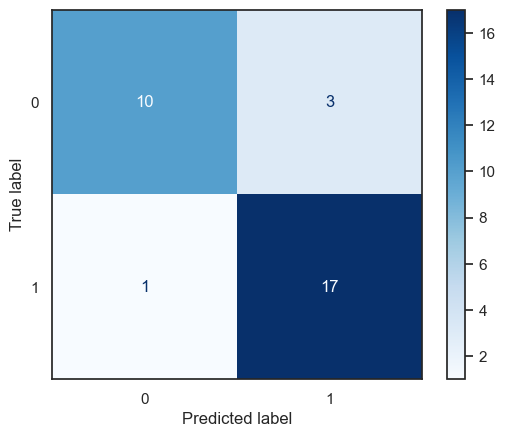

RandomForestClassifier()


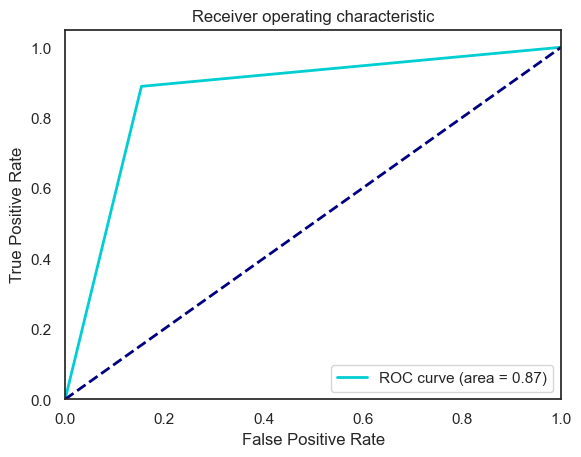

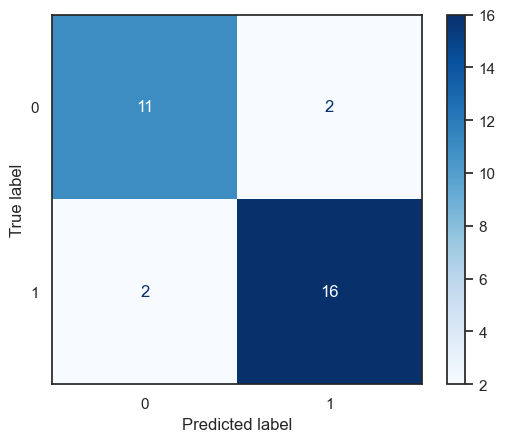

GradientBoostingClassifier()


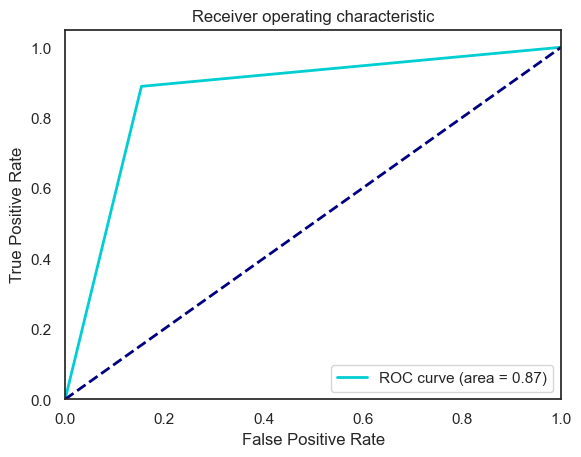

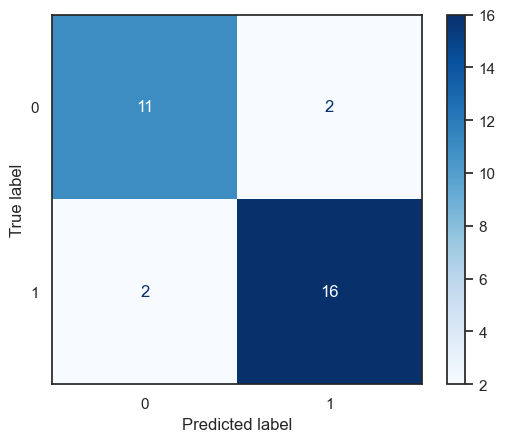

In [38]:
# Выполним обучение каждой модели из словаря clas_models, вычисляем и сохраняем метрики качества и результаты оценки производительности моделей.
for model_name, model in clas_models.items():
    train_model(model_name, model, clasMetricLogger)

### 9) Подбор гиперпараметров для выбранных моделей.

#### Метод ближайших соседей

In [39]:
n_range = np.array(range(1,100,1))
tuned_parameters = [{'n_neighbors': n_range}]
tuned_parameters

[{'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
         18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
         35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
         52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
         69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85,
         86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])}]

In [40]:
gs_KNN = GridSearchCV(KNeighborsClassifier(), tuned_parameters, cv=5, scoring='roc_auc')
gs_KNN.fit(X_train, Y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid=[{'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85,
       86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])}],
             scoring='roc_auc')

In [41]:
# Лучшая модель
gs_KNN.best_estimator_

KNeighborsClassifier(n_neighbors=19)

In [42]:
# Лучшее значение параметров
gs_KNN.best_params_

{'n_neighbors': 19}

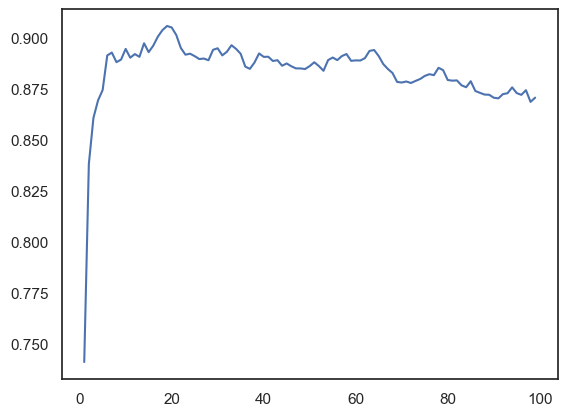

In [43]:
# Изменение качества на тестовой выборке
plt.plot(n_range, gs_KNN.cv_results_['mean_test_score'])

#### Логистическая регрессия

In [44]:
grid={"C":np.logspace(-3,3,3)}
gs_LogR = GridSearchCV(LogisticRegression(), grid, cv=5, scoring='roc_auc')
gs_LogR.fit(X_train, Y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': array([1.e-03, 1.e+00, 1.e+03])},
             scoring='roc_auc')

In [45]:
# Лучшая модель
gs_LogR.best_estimator_

LogisticRegression()

In [46]:
# Лучшее значение параметров
gs_LogR.best_params_

{'C': 1.0}

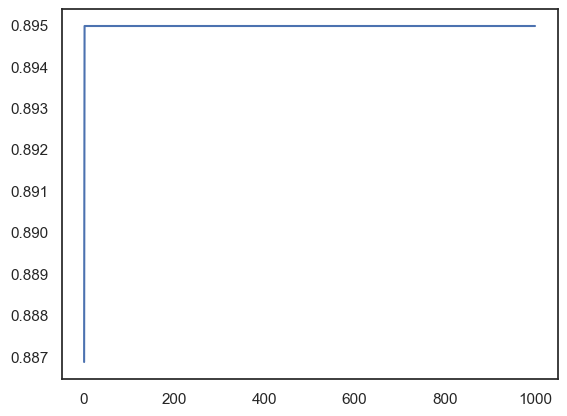

In [47]:
# Изменение качества на тестовой выборке
plt.plot(np.logspace(-3,3,3), gs_LogR.cv_results_['mean_test_score'])

#### Метод опорных векторов

In [48]:
SVC_grid={"C":np.logspace(-3,5,12)}
gs_SVC = GridSearchCV(SVC(), SVC_grid, cv=5, scoring='roc_auc')
gs_SVC.fit(X_train, Y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': array([1.00000000e-03, 5.33669923e-03, 2.84803587e-02, 1.51991108e-01,
       8.11130831e-01, 4.32876128e+00, 2.31012970e+01, 1.23284674e+02,
       6.57933225e+02, 3.51119173e+03, 1.87381742e+04, 1.00000000e+05])},
             scoring='roc_auc')

In [49]:
# Лучшая модель
gs_SVC.best_estimator_

SVC(C=4.328761281083062)

In [50]:
# Лучшее значение параметров
gs_SVC.best_params_

{'C': 4.328761281083062}

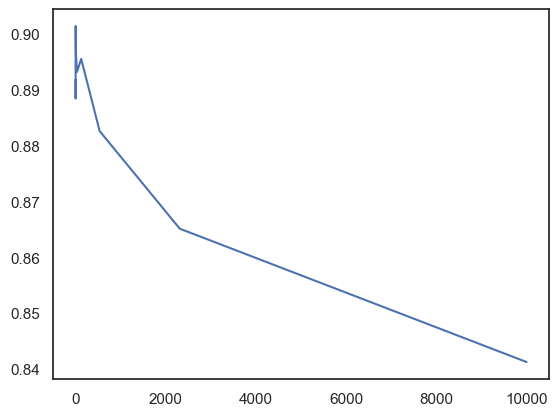

In [51]:
# Изменение качества на тестовой выборке
plt.plot(np.logspace(-3,4,12), gs_SVC.cv_results_['mean_test_score'])

#### Дерево решений

In [52]:
tree_params={"max_depth":range(1,20), "max_features":range(1,5)}
gs_Tree = GridSearchCV(DecisionTreeClassifier(), tree_params, cv=5, scoring='precision')
gs_Tree.fit(X_train, Y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': range(1, 20),
                         'max_features': range(1, 5)},
             scoring='precision')

In [53]:
# Лучшая модель
gs_Tree.best_estimator_

DecisionTreeClassifier(max_depth=1, max_features=4)

In [54]:
# Лучшее значение параметров
gs_Tree.best_params_

{'max_depth': 1, 'max_features': 4}

#### Случайный лес

In [55]:
RF_params={"max_leaf_nodes":range(2,12), "max_samples":range(2,22)}
gs_RF = GridSearchCV(RandomForestClassifier(), RF_params, cv=5, scoring='roc_auc')
gs_RF.fit(X_train, Y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_leaf_nodes': range(2, 12),
                         'max_samples': range(2, 22)},
             scoring='roc_auc')

In [56]:
# Лучшая модель
gs_RF.best_estimator_

RandomForestClassifier(max_leaf_nodes=11, max_samples=21)

In [57]:
# Лучшее значение параметров
gs_RF.best_params_

{'max_leaf_nodes': 11, 'max_samples': 21}

#### Градиентный бустинг

In [58]:
GB_params={"max_features":range(1,4), "max_leaf_nodes":range(2,22)}
gs_GB = GridSearchCV(GradientBoostingClassifier(), GB_params, cv=5, scoring='f1')
gs_GB.fit(X_train, Y_train)

GridSearchCV(cv=5, estimator=GradientBoostingClassifier(),
             param_grid={'max_features': range(1, 4),
                         'max_leaf_nodes': range(2, 22)},
             scoring='f1')

In [59]:
# Лучшая модель
gs_GB.best_estimator_

GradientBoostingClassifier(max_features=1, max_leaf_nodes=18)

In [60]:
# Лучшее значение параметров
gs_GB.best_params_

{'max_features': 1, 'max_leaf_nodes': 18}

### 10) Повторение пункта 8 для найденных оптимальных значений гиперпараметров. Сравнение качества полученных моделей с качеством baseline-моделей.

Предположительно, LogR_new, KNN_new, SVC_new, Tree_new, RF_new и GB_new - это объекты, полученные в результате перекрестной проверки (GridSearchCV), примененной к моделям логистической регрессии (Logistic Regression), метода k ближайших соседей (K-Nearest Neighbors), метода опорных векторов (Support Vector Classifier), дерева решений (Decision Tree), случайного леса (Random Forest) и градиентного бустинга (Gradient Boosting), соответственно. 

In [61]:
models_grid = { 'LogR_new':gs_LogR.best_estimator_,
               'KNN_new':gs_KNN.best_estimator_,
                'SVC_new':gs_SVC.best_estimator_,
              'Tree_new':gs_Tree.best_estimator_,
               'RF_new':gs_RF.best_estimator_,
              'GB_new':gs_GB.best_estimator_
              }

LogisticRegression()


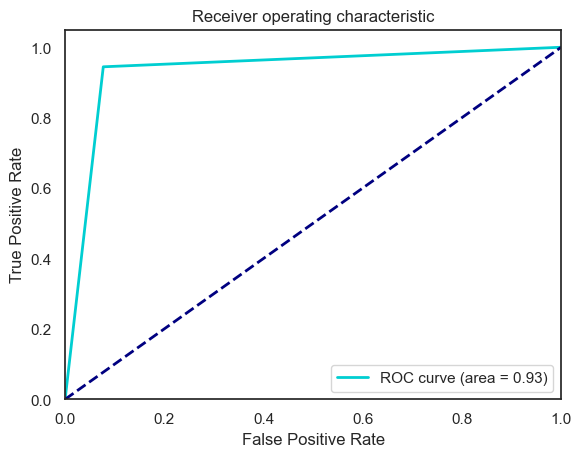

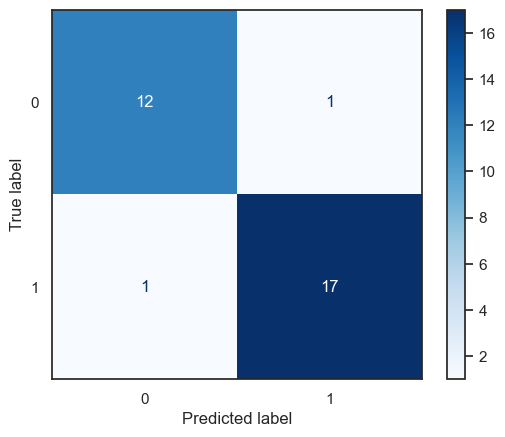

KNeighborsClassifier(n_neighbors=19)


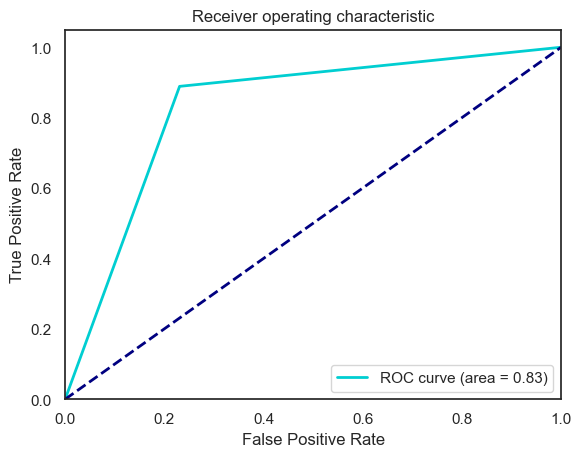

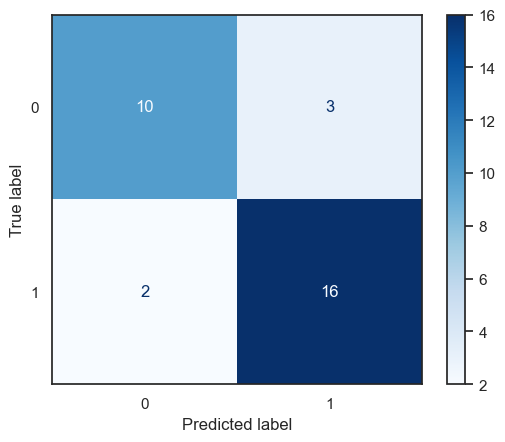

SVC(C=4.328761281083062)


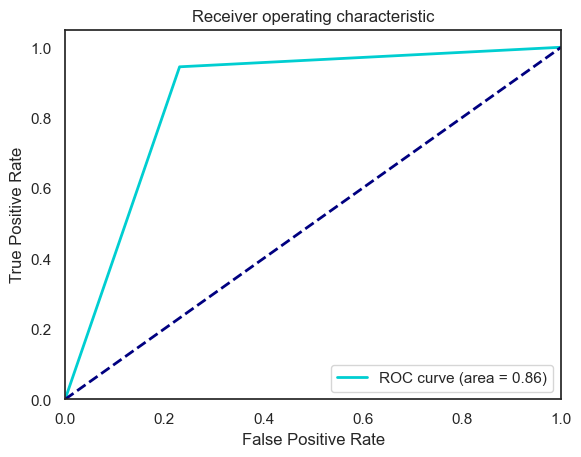

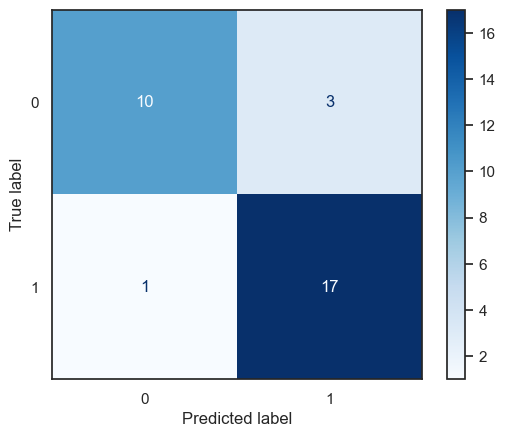

DecisionTreeClassifier(max_depth=1, max_features=4)


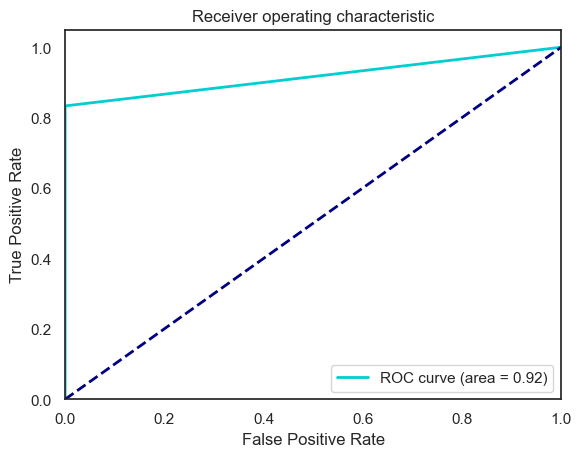

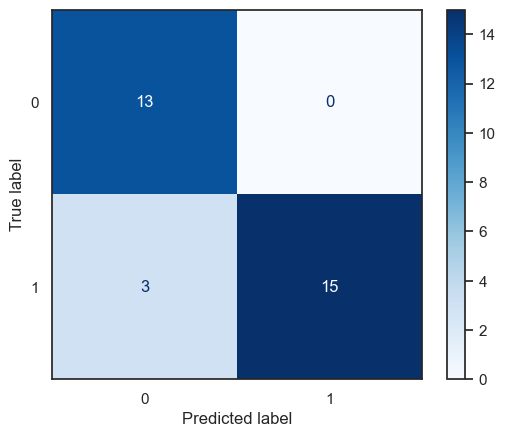

RandomForestClassifier(max_leaf_nodes=11, max_samples=21)


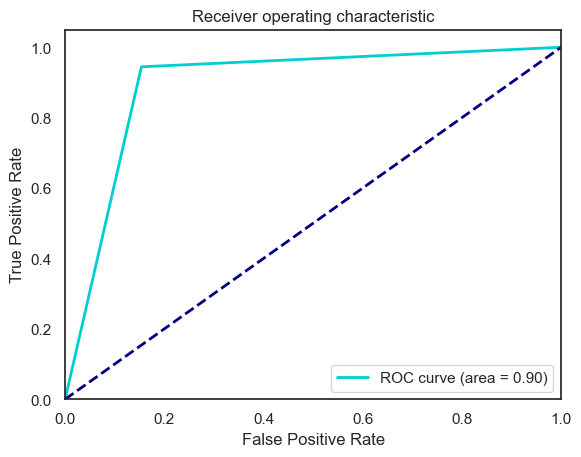

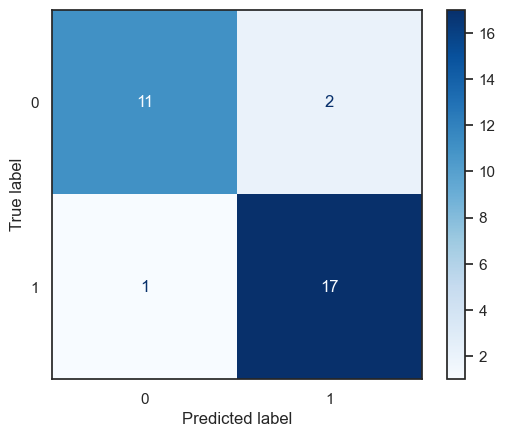

GradientBoostingClassifier(max_features=1, max_leaf_nodes=18)


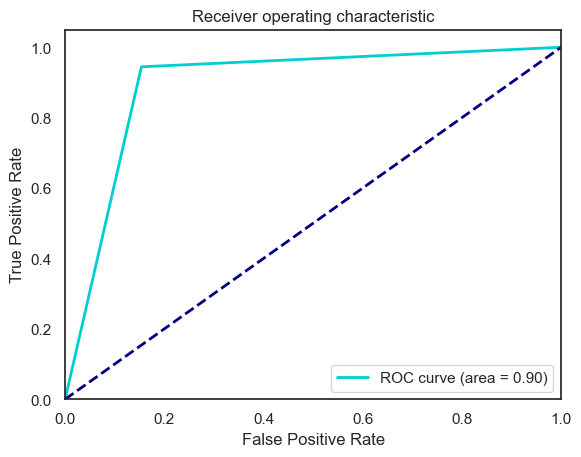

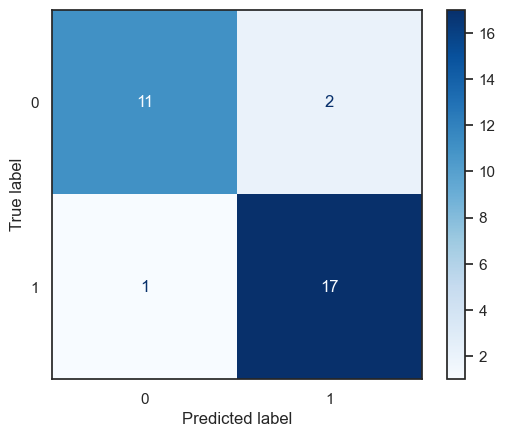

In [62]:
# Выполним обучение каждой модели из словаря models_grid, вычисляем и сохраняем метрики качества и результаты оценки производительности моделей.
for model_name, model in models_grid.items():
    train_model(model_name, model, clasMetricLogger)

### 11) Формирование выводов о качестве построенных моделей на основе выбранных метрик.

In [63]:
# Метрики качества модели
clas_metrics = clasMetricLogger.df['metric'].unique()
clas_metrics

array(['precision', 'recall', 'f1', 'roc_auc'], dtype=object)

In [64]:
for metric in clas_metrics:
    array_labels, array_metric = clasMetricLogger.get_data_for_metric(metric)
    print('Метрика:', metric)
    for label, value in zip(array_labels, array_metric):
        print(f'{label} : {value:.2f}')
    print('\n')

Метрика: precision
KNN_5 : 0.81
KNN_new : 0.84
SVC : 0.85
Tree : 0.85
SVC_new : 0.85
RF : 0.89
GB : 0.89
RF_new : 0.89
GB_new : 0.89
LogR : 0.94
LogR_new : 0.94
Tree_new : 1.00


Метрика: recall
Tree_new : 0.83
RF : 0.89
GB : 0.89
KNN_new : 0.89
LogR : 0.94
KNN_5 : 0.94
SVC : 0.94
Tree : 0.94
LogR_new : 0.94
SVC_new : 0.94
RF_new : 0.94
GB_new : 0.94


Метрика: f1
KNN_new : 0.86
KNN_5 : 0.87
RF : 0.89
GB : 0.89
SVC : 0.89
Tree : 0.89
SVC_new : 0.89
Tree_new : 0.91
RF_new : 0.92
GB_new : 0.92
LogR : 0.94
LogR_new : 0.94


Метрика: roc_auc
KNN_5 : 0.82
KNN_new : 0.83
SVC : 0.86
Tree : 0.86
SVC_new : 0.86
RF : 0.87
GB : 0.87
RF_new : 0.90
GB_new : 0.90
Tree_new : 0.92
LogR : 0.93
LogR_new : 0.93




Для наглядности результатов моделей, построим диаграмму

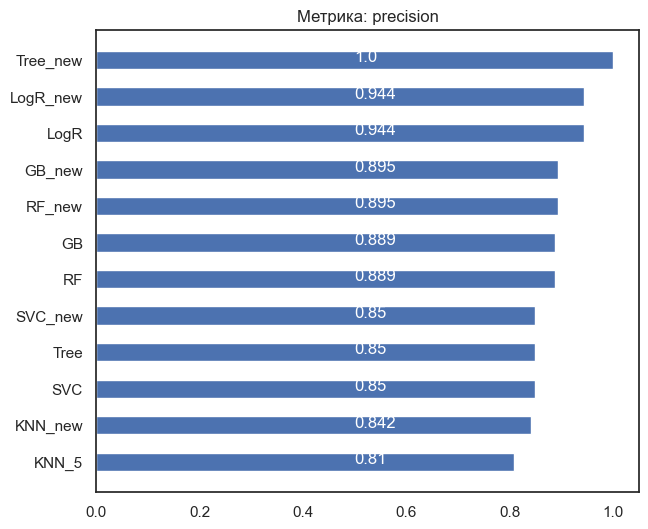

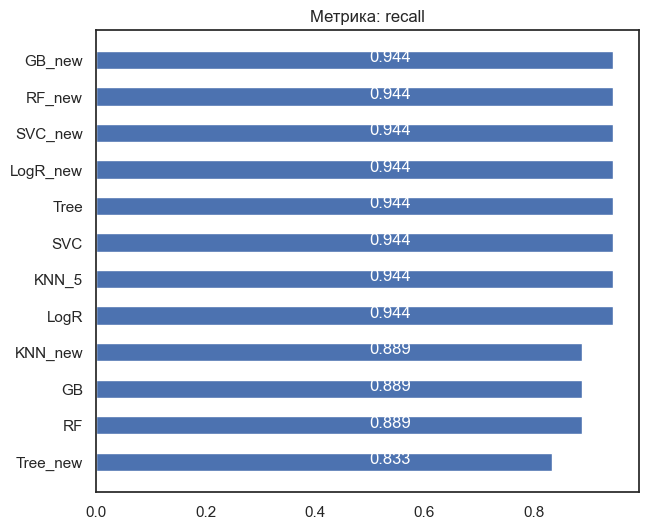

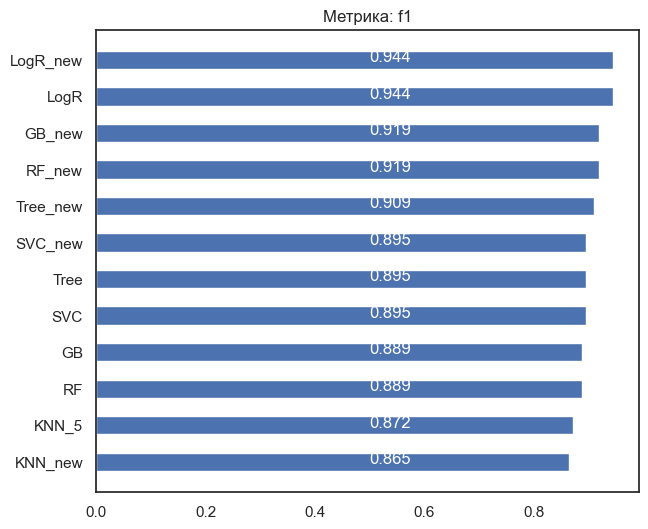

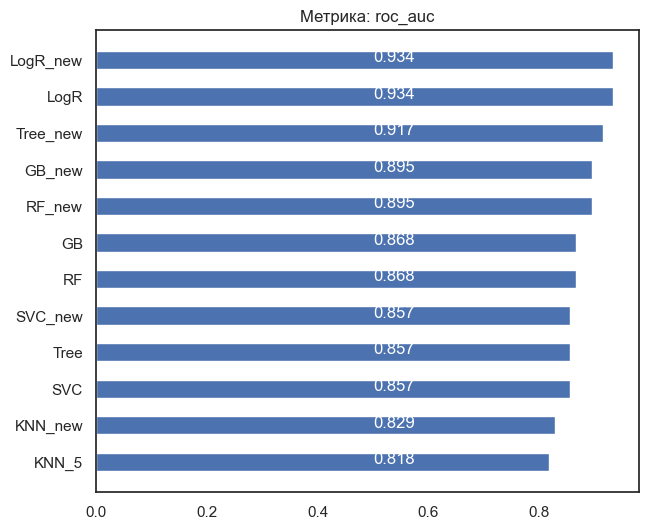

In [65]:
# Построим графики метрик качества модели
for metric in clas_metrics:
    clasMetricLogger.plot('Метрика: ' + metric, metric, figsize=(7, 6))

Из предоставленных метрик качества моделей можно сделать следующие выводы:

1) Точность (precision):

- Модели LogR, LogR_new, RF_new и Tree_new имеют самую высокую точность, равную примерно 0.94.
- Модели RF, GB, GB_new и Tree также обладают высокой точностью, около 0.89.
- Модель KNN_new имеет точность около 0.84, а модель KNN_5 - около 0.81.
- Модели SVC и SVC_new обладают точностью 0.85.

2) Полнота (recall):

- Модели Tree_new, RF, GB, KNN_new, GB_new, LogR, KNN_5, SVC, Tree, LogR_new и SVC_new имеют полноту около 0.94.

3) F1-мера (f1):

- Модели LogR, LogR_new и RF_new имеют высокие значения F1-меры, равные примерно 0.94.
- Модели Tree, Tree_new, SVC, SVC_new, GB и GB_new имеют F1-меру около 0.89.
- Модели KNN_new и KNN_5 имеют F1-меру около 0.86.

4) ROC AUC:

- Модели Tree_new, LogR, LogR_new и RF_new имеют высокие значения ROC AUC, близкие к 0.93.
- Модели Tree, GB и GB_new имеют значения ROC AUC около 0.87.
- Модели KNN_5 и KNN_new имеют ROC AUC около 0.82.
- Модели SVC и SVC_new обладают ROC AUC около 0.86.

Таким образом, можно сделать вывод, что модели, обученные с использованием логистической регрессии и случайного леса, показывают наилучшее общее качество, выраженное высокими значениями метрик точности, полноты, F1-меры и ROC AUC. 